In [23]:
#model_data = model_data.sort_values("title").reset_index(drop=True)
#model_data.to_csv("data/model_data.csv", index=False)

In [1]:
import pandas as pd
import numpy as np

model_data = pd.read_csv("data/model_data.csv")

feature_cols = [c for c in model_data.columns if c not in ["title", "is_profitable"]]
X = model_data[feature_cols]
y = model_data["is_profitable"]

print(X.shape)
print(feature_cols)

(5264, 28)
['budget', 'runtime', 'release_year', 'month_sin', 'month_cos', 'is_franchise', 'is_english', 'is_major_studio', 'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [25]:
from sklearn.model_selection import train_test_split

X = X.copy()
X["budget"] = np.log10(X["budget"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape, X_test.shape)
print("Baseline (always guess profitable):", round(y_test.mean(), 3))

(4211, 28) (1053, 28)
Baseline (always guess profitable): 0.705


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(3, 202, 4)),
    "knn__weights": ["uniform", "distance"]
}

knn_search = GridSearchCV(knn_pipe, param_grid, cv=5, scoring="roc_auc")
knn_search.fit(X_train, y_train)

print("Best settings:", knn_search.best_params_)
print("Best cross-validated ROC AUC:", round(knn_search.best_score_, 3))

Best settings: {'knn__n_neighbors': 87, 'knn__weights': 'distance'}
Best cross-validated ROC AUC: 0.708


Test accuracy: 0.711
Test ROC AUC: 0.693
                precision    recall  f1-score   support

Not profitable       0.56      0.10      0.17       311
    Profitable       0.72      0.97      0.83       742

      accuracy                           0.71      1053
     macro avg       0.64      0.53      0.50      1053
  weighted avg       0.67      0.71      0.63      1053



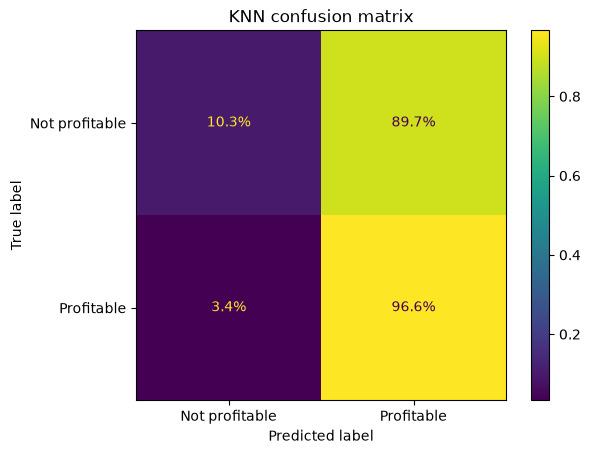

In [27]:
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

best_knn = knn_search.best_estimator_
y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)[:, 1]

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Test ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))
print(classification_report(y_test, y_pred, target_names=["Not profitable", "Profitable"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Not profitable", "Profitable"],
                                        normalize="true", values_format=".1%")
plt.title("KNN confusion matrix")
plt.show()

Best threshold: 0.7
Balanced accuracy (0.5 cutoff): 0.535
Balanced accuracy (tuned cutoff): 0.635
                precision    recall  f1-score   support

Not profitable       0.40      0.72      0.52       311
    Profitable       0.82      0.55      0.66       742

      accuracy                           0.60      1053
     macro avg       0.61      0.63      0.59      1053
  weighted avg       0.70      0.60      0.62      1053



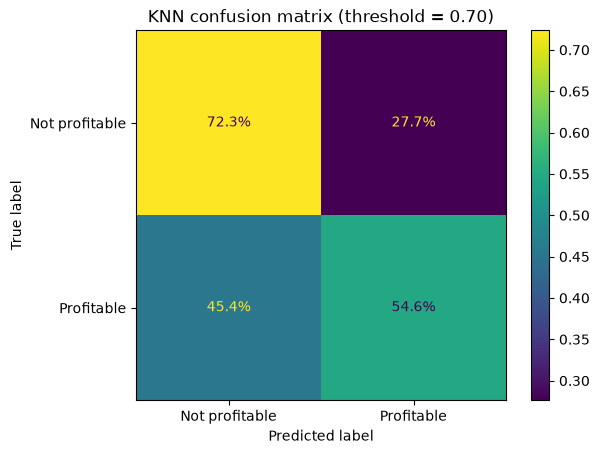

In [28]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import balanced_accuracy_score

# Out-of-fold probabilities on the training set
train_prob = cross_val_predict(best_knn, X_train, y_train, cv=5, method="predict_proba")[:, 1]

# Try thresholds and keep the one with the best balanced accuracy
thresholds = np.arange(0.3, 0.9, 0.01)
scores = [balanced_accuracy_score(y_train, (train_prob >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(scores)]
print("Best threshold:", round(best_t, 2))

# Apply it to the test set
y_pred_t = (y_prob >= best_t).astype(int)
print("Balanced accuracy (0.5 cutoff):", round(balanced_accuracy_score(y_test, y_pred), 3))
print("Balanced accuracy (tuned cutoff):", round(balanced_accuracy_score(y_test, y_pred_t), 3))
print(classification_report(y_test, y_pred_t, target_names=["Not profitable", "Profitable"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_t, display_labels=["Not profitable", "Profitable"],
                                        normalize="true", values_format=".1%")
plt.title(f"KNN confusion matrix (threshold = {best_t:.2f})")
plt.show()

In [29]:
from sklearn.tree import DecisionTreeClassifier

tree_params = {
    "max_depth": [3, 4, 5, 6, 8, 10, 12, None],
    "min_samples_leaf": [1, 5, 10, 20, 50, 100]
}

tree_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           tree_params, cv=5, scoring="roc_auc")
tree_search.fit(X_train, y_train)

print("Best settings:", tree_search.best_params_)
print("Best cross-validated ROC AUC:", round(tree_search.best_score_, 3))

Best settings: {'max_depth': 6, 'min_samples_leaf': 50}
Best cross-validated ROC AUC: 0.722


Test ROC AUC: 0.707
Best threshold: 0.68
Accuracy (0.5 / tuned): 0.697 / 0.642
Balanced accuracy (0.5 / tuned): 0.543 / 0.672
                precision    recall  f1-score   support

Not profitable       0.44      0.75      0.55       311
    Profitable       0.85      0.60      0.70       742

      accuracy                           0.64      1053
     macro avg       0.64      0.67      0.63      1053
  weighted avg       0.73      0.64      0.66      1053



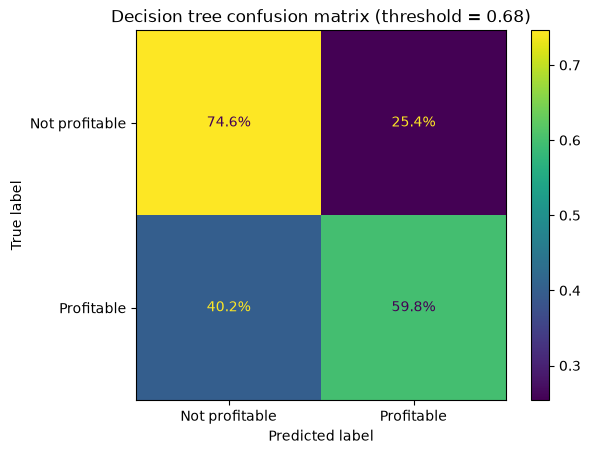

In [30]:
best_tree = tree_search.best_estimator_
tree_prob = best_tree.predict_proba(X_test)[:, 1]
tree_pred = best_tree.predict(X_test)

# Choose the cutoff on training data only
train_prob_tree = cross_val_predict(best_tree, X_train, y_train, cv=5, method="predict_proba")[:, 1]
scores = [balanced_accuracy_score(y_train, (train_prob_tree >= t).astype(int)) for t in thresholds]
tree_t = thresholds[np.argmax(scores)]
tree_pred_t = (tree_prob >= tree_t).astype(int)

print("Test ROC AUC:", round(roc_auc_score(y_test, tree_prob), 3))
print("Best threshold:", round(tree_t, 2))
print("Accuracy (0.5 / tuned):", round(accuracy_score(y_test, tree_pred), 3), "/",
      round(accuracy_score(y_test, tree_pred_t), 3))
print("Balanced accuracy (0.5 / tuned):", round(balanced_accuracy_score(y_test, tree_pred), 3), "/",
      round(balanced_accuracy_score(y_test, tree_pred_t), 3))
print(classification_report(y_test, tree_pred_t, target_names=["Not profitable", "Profitable"]))

ConfusionMatrixDisplay.from_predictions(y_test, tree_pred_t, display_labels=["Not profitable", "Profitable"],
                                        normalize="true", values_format=".1%")
plt.title(f"Decision tree confusion matrix (threshold = {tree_t:.2f})")
plt.show()

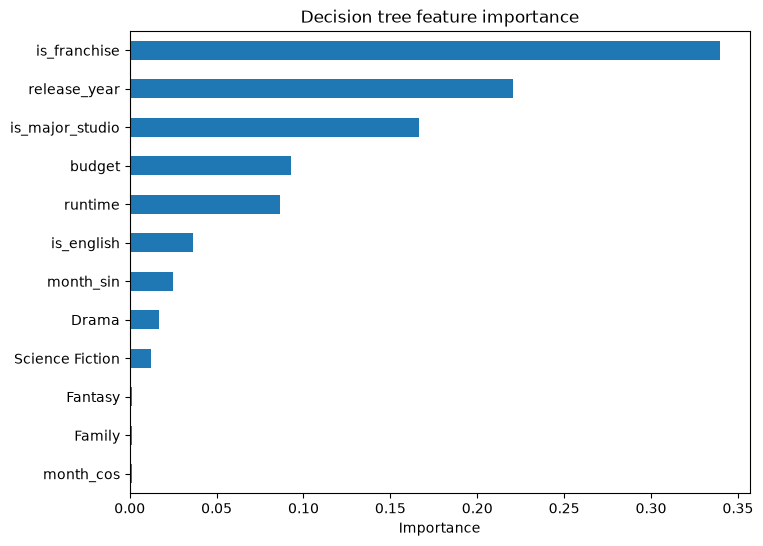

is_franchise       0.340
release_year       0.221
is_major_studio    0.167
budget             0.093
runtime            0.086
is_english         0.037
month_sin          0.025
Drama              0.017
Science Fiction    0.012
Fantasy            0.001
Family             0.001
month_cos          0.001
dtype: float64


In [31]:
importances = pd.Series(best_tree.feature_importances_, index=X_train.columns)
importances = importances[importances > 0].sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.title("Decision tree feature importance")
plt.xlabel("Importance")
plt.show()

print(importances.sort_values(ascending=False).round(3))

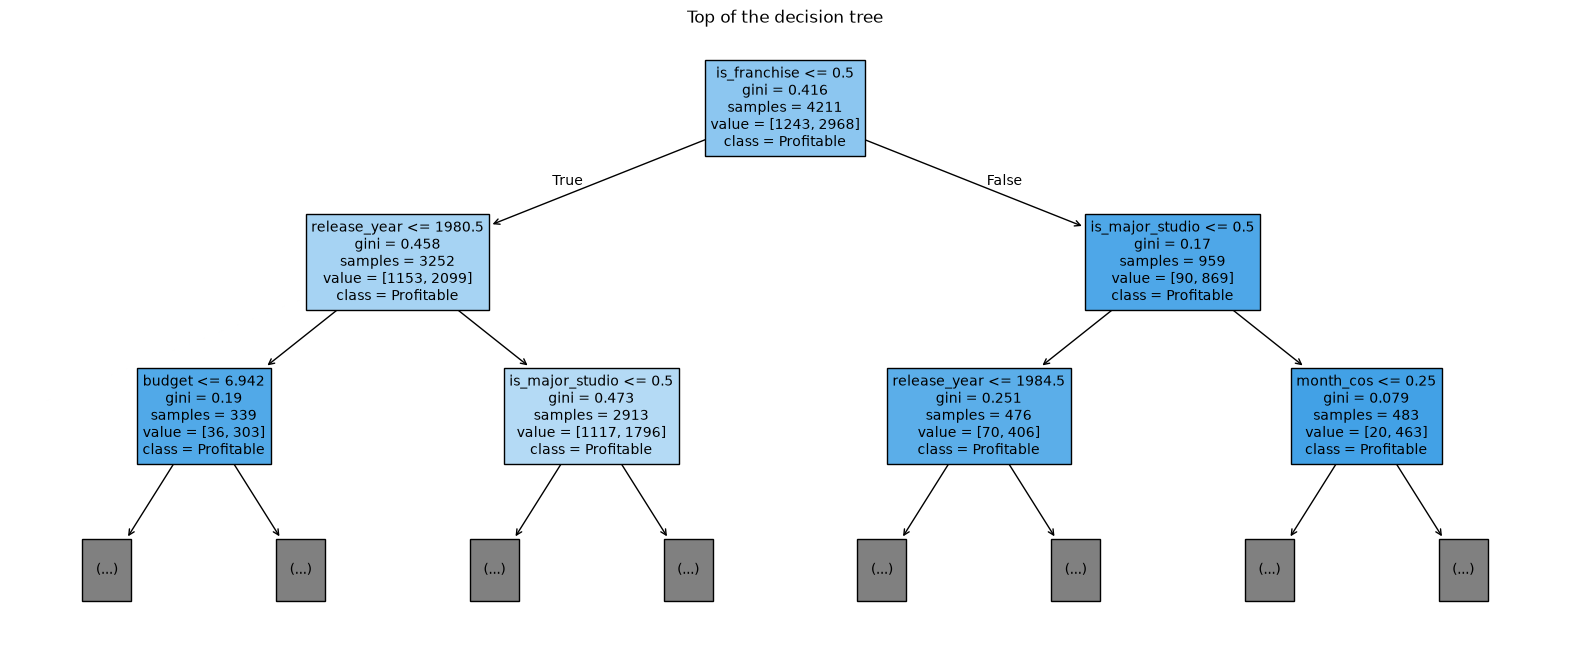

In [32]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(best_tree, max_depth=2, feature_names=X_train.columns,
          class_names=["Not profitable", "Profitable"], filled=True, fontsize=10)
plt.title("Top of the decision tree")
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    "max_depth": [6, 10, 15, None],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["sqrt", 0.5]
}

rf_search = GridSearchCV(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
                         rf_params, cv=5, scoring="roc_auc")
rf_search.fit(X_train, y_train)

print("Best settings:", rf_search.best_params_)
print("Best cross-validated ROC AUC:", round(rf_search.best_score_, 3))

Best settings: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5}
Best cross-validated ROC AUC: 0.751


Test ROC AUC: 0.716
Best threshold: 0.73
Accuracy (0.5 / tuned): 0.708 / 0.612
Balanced accuracy (0.5 / tuned): 0.56 / 0.659
                precision    recall  f1-score   support

Not profitable       0.42      0.77      0.54       311
    Profitable       0.85      0.54      0.66       742

      accuracy                           0.61      1053
     macro avg       0.63      0.66      0.60      1053
  weighted avg       0.72      0.61      0.63      1053



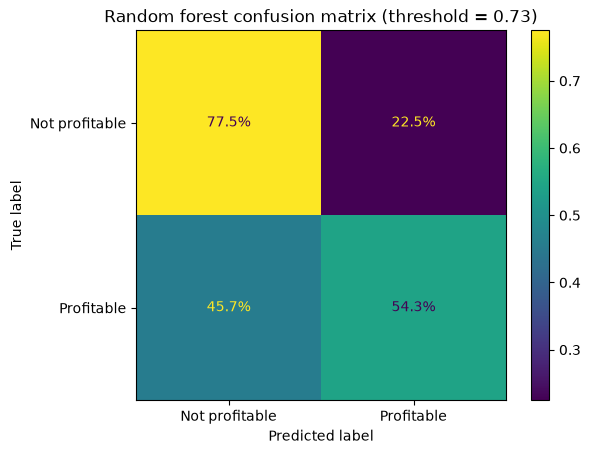

In [34]:
best_rf = rf_search.best_estimator_
rf_prob = best_rf.predict_proba(X_test)[:, 1]
rf_pred = best_rf.predict(X_test)

train_prob_rf = cross_val_predict(best_rf, X_train, y_train, cv=5, method="predict_proba")[:, 1]
scores = [balanced_accuracy_score(y_train, (train_prob_rf >= t).astype(int)) for t in thresholds]
rf_t = thresholds[np.argmax(scores)]
rf_pred_t = (rf_prob >= rf_t).astype(int)

print("Test ROC AUC:", round(roc_auc_score(y_test, rf_prob), 3))
print("Best threshold:", round(rf_t, 2))
print("Accuracy (0.5 / tuned):", round(accuracy_score(y_test, rf_pred), 3), "/",
      round(accuracy_score(y_test, rf_pred_t), 3))
print("Balanced accuracy (0.5 / tuned):", round(balanced_accuracy_score(y_test, rf_pred), 3), "/",
      round(balanced_accuracy_score(y_test, rf_pred_t), 3))
print(classification_report(y_test, rf_pred_t, target_names=["Not profitable", "Profitable"]))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred_t, display_labels=["Not profitable", "Profitable"],
                                        normalize="true", values_format=".1%")
plt.title(f"Random forest confusion matrix (threshold = {rf_t:.2f})")
plt.show()

In [35]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (accuracy_score, roc_auc_score, balanced_accuracy_score,
                             classification_report, ConfusionMatrixDisplay)
thresholds = np.arange(0.3, 0.9, 0.01)

In [36]:
def evaluate(model, name):
    prob = model.predict_proba(X_test)[:, 1]
    train_prob = cross_val_predict(model, X_train, y_train, cv=5, method="predict_proba")[:, 1]
    scores = [balanced_accuracy_score(y_train, (train_prob >= t).astype(int)) for t in thresholds]
    t_best = thresholds[np.argmax(scores)]
    pred_t = (prob >= t_best).astype(int)

    print(f"{name}  |  Test ROC AUC: {roc_auc_score(y_test, prob):.3f}  |  threshold: {t_best:.2f}")
    print(f"Accuracy: {accuracy_score(y_test, pred_t):.3f}  |  Balanced accuracy: {balanced_accuracy_score(y_test, pred_t):.3f}")
    print(classification_report(y_test, pred_t, target_names=["Not profitable", "Profitable"]))
    ConfusionMatrixDisplay.from_predictions(y_test, pred_t, display_labels=["Not profitable", "Profitable"],
                                            normalize="true", values_format=".1%")
    plt.title(f"{name} confusion matrix (threshold = {t_best:.2f})")
    plt.show()

Best settings: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 50}
Best cross-validated ROC AUC: 0.749
Gradient boosting  |  Test ROC AUC: 0.717  |  threshold: 0.71
Accuracy: 0.628  |  Balanced accuracy: 0.654
                precision    recall  f1-score   support

Not profitable       0.42      0.72      0.53       311
    Profitable       0.83      0.59      0.69       742

      accuracy                           0.63      1053
     macro avg       0.63      0.65      0.61      1053
  weighted avg       0.71      0.63      0.64      1053



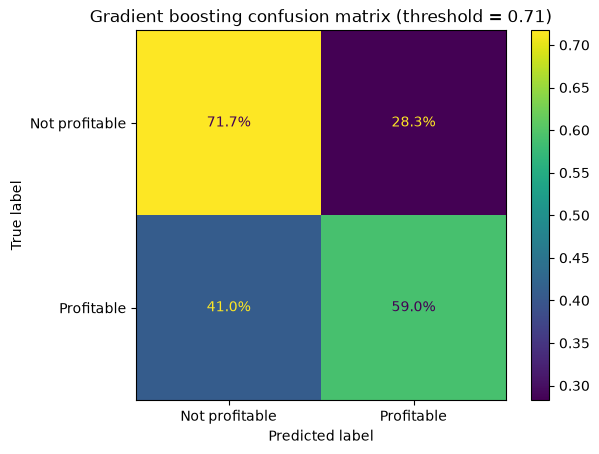

In [37]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_params = {
    "learning_rate": [0.03, 0.1],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [20, 50]
}

gb_search = GridSearchCV(HistGradientBoostingClassifier(max_iter=300, early_stopping=True, random_state=42),
                         gb_params, cv=5, scoring="roc_auc")
gb_search.fit(X_train, y_train)
print("Best settings:", gb_search.best_params_)
print("Best cross-validated ROC AUC:", round(gb_search.best_score_, 3))

evaluate(gb_search.best_estimator_, "Gradient boosting")

In [38]:
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

nn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPClassifier(max_iter=1000, early_stopping=True, random_state=42))
])

nn_params = {
    "nn__hidden_layer_sizes": [(16,), (32,), (64,), (32, 16), (64, 32)],
    "nn__alpha": [0.001, 0.01, 0.1, 1.0],
    "nn__learning_rate_init": [0.001, 0.01]
}

nn_search = GridSearchCV(nn_pipe, nn_params, cv=5, scoring="roc_auc", n_jobs=-1)
nn_search.fit(X_train, y_train)

print("Best settings:", nn_search.best_params_)
print("Best cross-validated ROC AUC:", round(nn_search.best_score_, 3))

Best settings: {'nn__alpha': 1.0, 'nn__hidden_layer_sizes': (16,), 'nn__learning_rate_init': 0.01}
Best cross-validated ROC AUC: 0.744


Neural network  |  Test ROC AUC: 0.699  |  threshold: 0.68
Accuracy: 0.655  |  Balanced accuracy: 0.661
                precision    recall  f1-score   support

Not profitable       0.44      0.68      0.54       311
    Profitable       0.83      0.65      0.73       742

      accuracy                           0.66      1053
     macro avg       0.64      0.66      0.63      1053
  weighted avg       0.71      0.66      0.67      1053



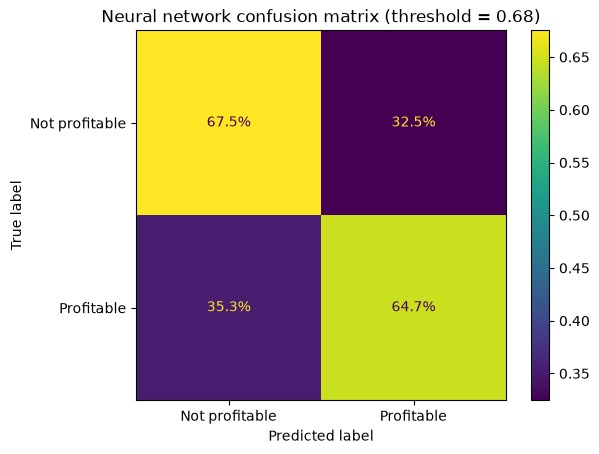

In [39]:
evaluate(nn_search.best_estimator_, "Neural network")

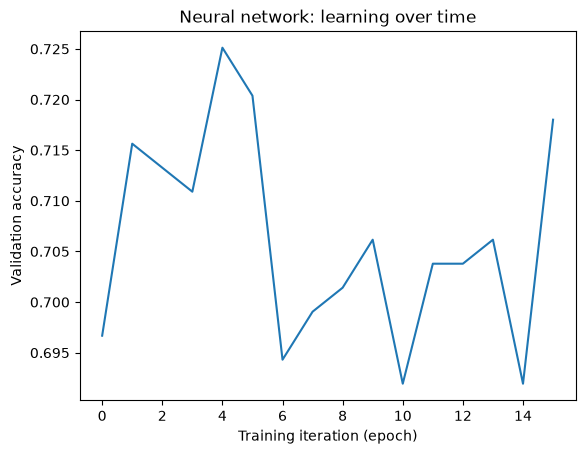

Stopped after 16 iterations


In [40]:
best_nn = nn_search.best_estimator_.named_steps["nn"]
plt.plot(best_nn.validation_scores_)
plt.xlabel("Training iteration (epoch)")
plt.ylabel("Validation accuracy")
plt.title("Neural network: learning over time")
plt.show()
print("Stopped after", best_nn.n_iter_, "iterations")

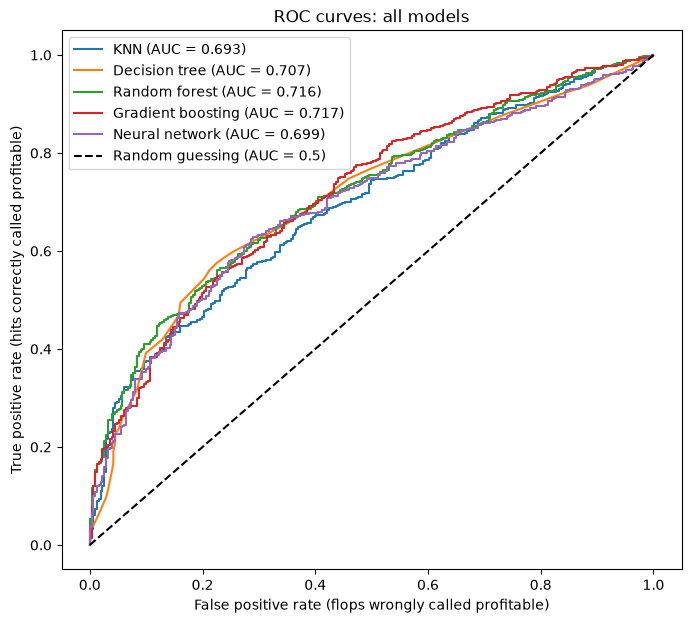

,Model,CV ROC AUC,Test ROC AUC,Balanced accuracy,Accuracy,Threshold
3,Gradient boosting,0.749,0.717,0.654,0.628,0.71
2,Random forest,0.751,0.716,0.659,0.612,0.73
1,Decision tree,0.722,0.707,0.672,0.642,0.68
4,Neural network,0.744,0.699,0.661,0.655,0.68
0,KNN,0.708,0.693,0.635,0.598,0.70


In [41]:
from sklearn.metrics import roc_curve

models = {
    "KNN": (knn_search.best_estimator_, knn_search.best_score_),
    "Decision tree": (tree_search.best_estimator_, tree_search.best_score_),
    "Random forest": (rf_search.best_estimator_, rf_search.best_score_),
    "Gradient boosting": (gb_search.best_estimator_, gb_search.best_score_),
    "Neural network": (nn_search.best_estimator_, nn_search.best_score_),
}

rows = []
plt.figure(figsize=(8, 7))
for name, (model, cv_auc) in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    train_prob = cross_val_predict(model, X_train, y_train, cv=5, method="predict_proba")[:, 1]
    t = thresholds[np.argmax([balanced_accuracy_score(y_train, (train_prob >= t).astype(int)) for t in thresholds])]
    pred = (prob >= t).astype(int)
    rows.append({"Model": name, "CV ROC AUC": cv_auc, "Test ROC AUC": roc_auc_score(y_test, prob),
                 "Balanced accuracy": balanced_accuracy_score(y_test, pred),
                 "Accuracy": accuracy_score(y_test, pred), "Threshold": t})
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, prob):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guessing (AUC = 0.5)")
plt.xlabel("False positive rate (flops wrongly called profitable)")
plt.ylabel("True positive rate (hits correctly called profitable)")
plt.title("ROC curves: all models")
plt.legend()
plt.show()

comparison = pd.DataFrame(rows).sort_values("Test ROC AUC", ascending=False).round(3)
comparison

Best settings: {'lr__C': 1}
Best cross-validated ROC AUC: 0.715
Logistic regression  |  Test ROC AUC: 0.677  |  threshold: 0.68
Accuracy: 0.641  |  Balanced accuracy: 0.637
                precision    recall  f1-score   support

Not profitable       0.43      0.63      0.51       311
    Profitable       0.81      0.65      0.72       742

      accuracy                           0.64      1053
     macro avg       0.62      0.64      0.61      1053
  weighted avg       0.69      0.64      0.66      1053



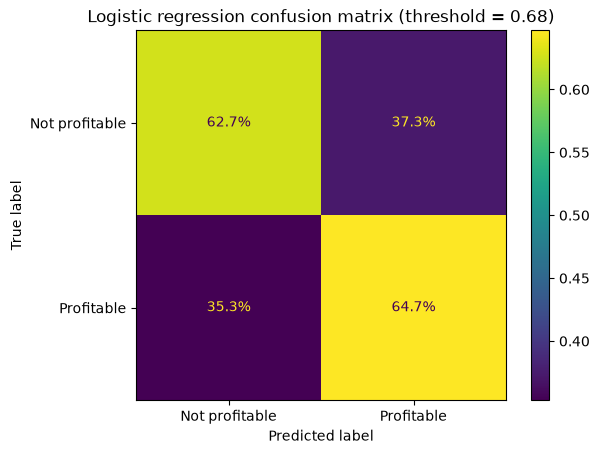

In [42]:
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

lr_search = GridSearchCV(lr_pipe, {"lr__C": [0.001, 0.01, 0.1, 1, 10]},
                         cv=5, scoring="roc_auc")
lr_search.fit(X_train, y_train)

print("Best settings:", lr_search.best_params_)
print("Best cross-validated ROC AUC:", round(lr_search.best_score_, 3))

evaluate(lr_search.best_estimator_, "Logistic regression")

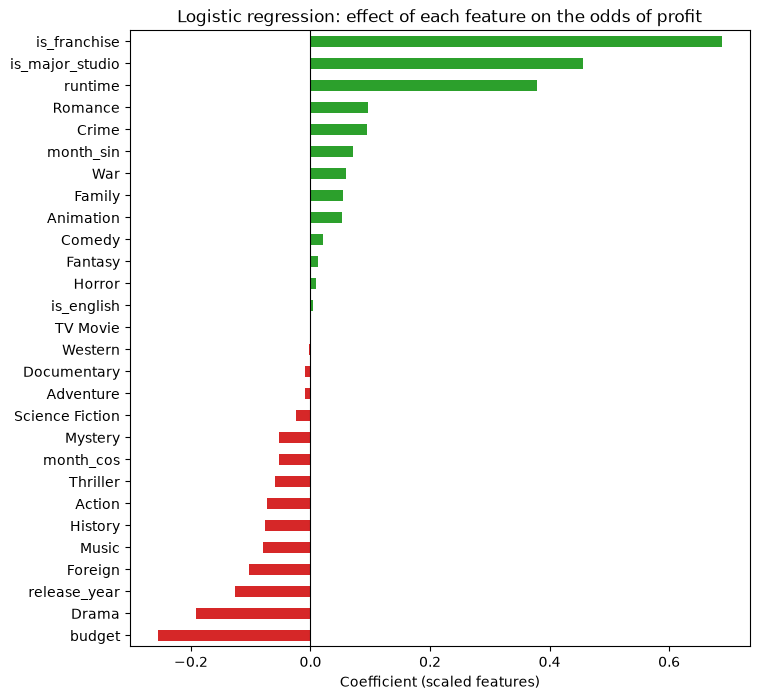

In [43]:
coefs = pd.Series(lr_search.best_estimator_.named_steps["lr"].coef_[0],
                  index=X_train.columns).sort_values()

plt.figure(figsize=(8, 8))
colors = ["tab:red" if c < 0 else "tab:green" for c in coefs]
coefs.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic regression: effect of each feature on the odds of profit")
plt.xlabel("Coefficient (scaled features)")
plt.show()

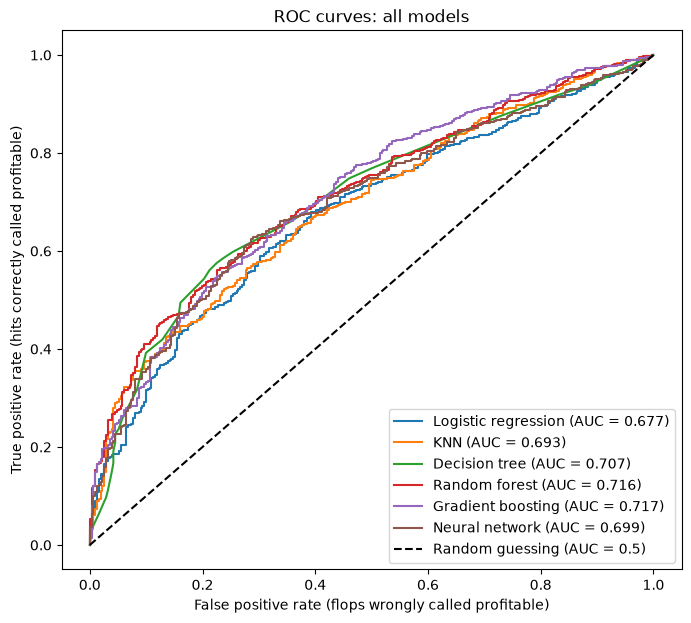

,Model,CV ROC AUC,Test ROC AUC,Balanced accuracy,Accuracy,Threshold
0,Random forest,0.751,0.716,0.659,0.612,0.73
1,Gradient boosting,0.749,0.717,0.654,0.628,0.71
2,Neural network,0.744,0.699,0.661,0.655,0.68
3,Decision tree,0.722,0.707,0.672,0.642,0.68
4,Logistic regression,0.715,0.677,0.637,0.641,0.68
5,KNN,0.708,0.693,0.635,0.598,0.70


In [44]:
from sklearn.metrics import roc_curve

models = {
    "Logistic regression": (lr_search.best_estimator_, lr_search.best_score_),
    "KNN": (knn_search.best_estimator_, knn_search.best_score_),
    "Decision tree": (tree_search.best_estimator_, tree_search.best_score_),
    "Random forest": (rf_search.best_estimator_, rf_search.best_score_),
    "Gradient boosting": (gb_search.best_estimator_, gb_search.best_score_),
    "Neural network": (nn_search.best_estimator_, nn_search.best_score_),
}

rows = []
plt.figure(figsize=(8, 7))
for name, (model, cv_auc) in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    train_prob = cross_val_predict(model, X_train, y_train, cv=5, method="predict_proba")[:, 1]
    t = thresholds[np.argmax([balanced_accuracy_score(y_train, (train_prob >= t).astype(int)) for t in thresholds])]
    pred = (prob >= t).astype(int)
    rows.append({"Model": name, "CV ROC AUC": cv_auc, "Test ROC AUC": roc_auc_score(y_test, prob),
                 "Balanced accuracy": balanced_accuracy_score(y_test, pred),
                 "Accuracy": accuracy_score(y_test, pred), "Threshold": t})
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, prob):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guessing (AUC = 0.5)")
plt.xlabel("False positive rate (flops wrongly called profitable)")
plt.ylabel("True positive rate (hits correctly called profitable)")
plt.title("ROC curves: all models")
plt.legend()
plt.show()

comparison = pd.DataFrame(rows).sort_values("CV ROC AUC", ascending=False).reset_index(drop=True).round(3)
comparison